In [7]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']


In [8]:
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
      .sum()
      .reset_index()
)

daily_sales.columns = ['ds', 'y']

daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

In [9]:
daily_sales.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [10]:
daily_sales.shape

(305, 2)

In [12]:
daily_sales.to_csv(
    r'C:\Users\HP\Desktop\retailpulse_project\data\processed\daily_sales.csv',
    index=False
)

print("Daily sales dataset saved successfully")

Daily sales dataset saved successfully


In [13]:
daily_sales.isnull().sum()

ds    0
y     0
dtype: int64

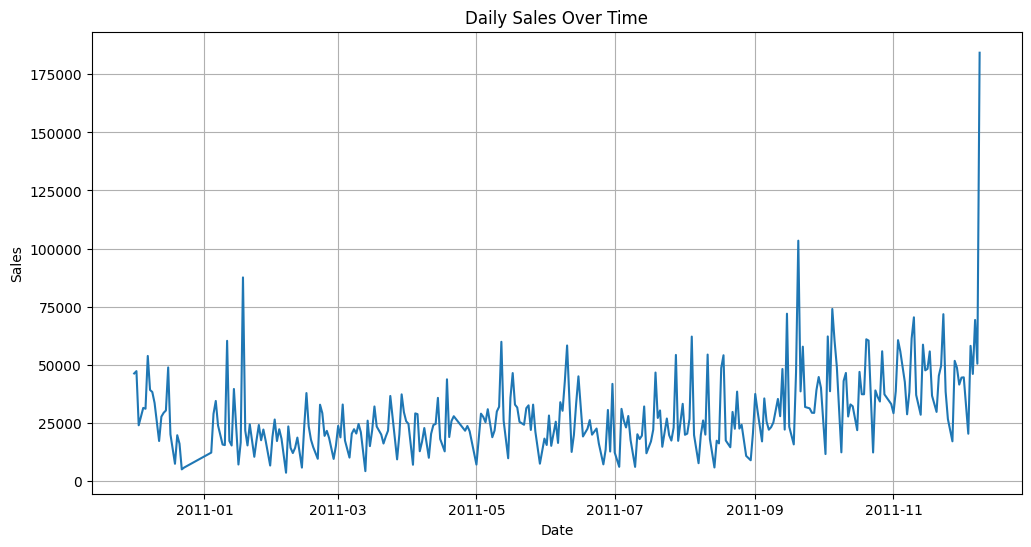

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_sales['ds'], daily_sales['y'])

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [15]:
daily_sales['y'].describe()

count       305.000000
mean      29138.389816
std       17834.947344
min        3439.670000
25%       17999.181000
50%       25351.440000
75%       36606.250000
max      184329.660000
Name: y, dtype: float64

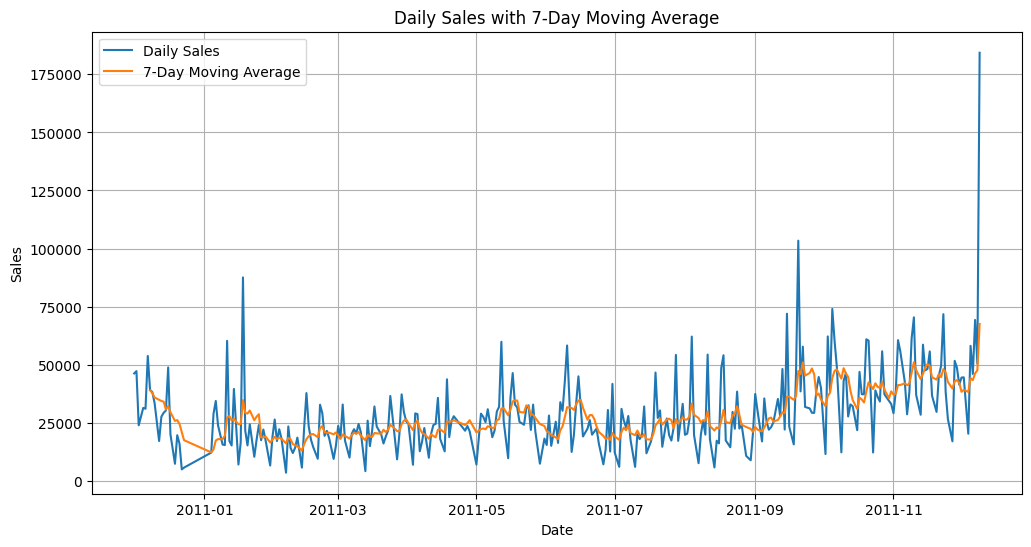

In [17]:
daily_sales['7_day_ma'] = daily_sales['y'].rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_sales['ds'], daily_sales['y'], label='Daily Sales')
plt.plot(daily_sales['ds'], daily_sales['7_day_ma'], label='7-Day Moving Average')

plt.title("Daily Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales['y'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.3709399314642723
p-value: 0.9148388731385403
Critical Values:
1%: -3.452867117291862
5%: -2.8714554160827745
10%: -2.5720532321867466


In [20]:
daily_sales['y_diff'] = daily_sales['y'].diff()

daily_sales.head()

,ds,y,7_day_ma,y_diff
0,2010-12-01,46192.49,NaN,NaN
1,2010-12-02,47197.57,NaN,1005.08
2,2010-12-03,23876.63,NaN,-23320.94
3,2010-12-05,31361.28,NaN,7484.65
4,2010-12-06,31009.33,NaN,-351.95


In [21]:
# to remove NaN 

daily_sales_diff = daily_sales.dropna()

daily_sales_diff.head()

,ds,y,7_day_ma,y_diff
6,2010-12-08,39094.20,38923.208571,-14636.76
7,2010-12-09,38193.91,37780.554286,-900.29
8,2010-12-10,33488.38,35822.098571,-4705.53
9,2010-12-12,17102.35,34854.344286,-16386.03
10,2010-12-13,27578.34,34313.924286,10475.99


In [22]:
from statsmodels.tsa.stattools import adfuller

result_diff = adfuller(daily_sales_diff['y_diff'])

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -6.344223959301419
p-value: 2.7077405586223573e-08
1%: -3.453342167806272
5%: -2.871663828287282
10%: -2.572164381381345


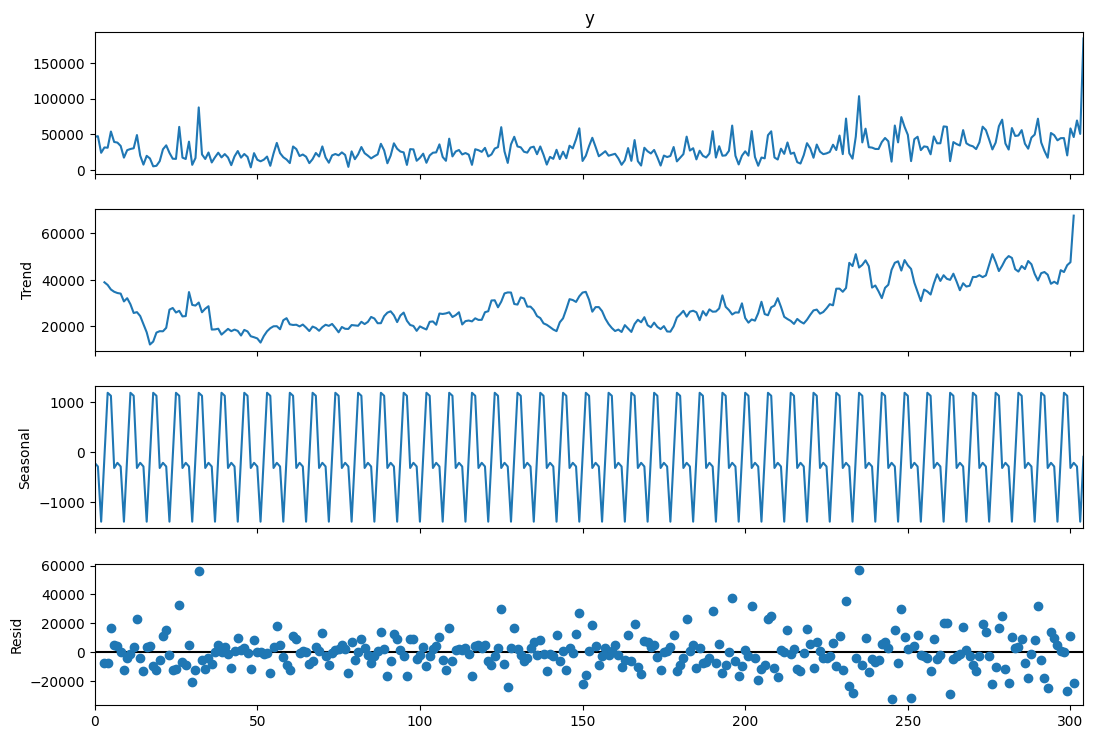

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(
    daily_sales['y'],
    model='additive',
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()